# MNIST Classifier (Original Dataspace) + Classifying DDPM Samples

Trains a classifier on **original MNIST** pixels (in **[0,1]** with the standard MNIST normalization.
It also includes helper code to classify samples from your diffusion notebook after `undo_precond()`.


In [4]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys, os

print(sys.executable)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Allocated: {round(torch.cuda.memory_allocated(0)/1024**3,1)} GB")


/home/hoffmanp/diff_env/.venv/bin/python
device: cuda
GPU Name: NVIDIA L40S
Allocated: 0.0 GB


In [5]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("Seed set to:", seed)

SEED = 2026
set_seed(SEED)


Seed set to: 2026


## 1) Choose the classifier input space

### Recommended (default): **[0,1]** with standard MNIST normalization
- Train on `ToTensor()` output in **[0,1]** and apply `Normalize(mean=0.1307, std=0.3081)`.
- To classify diffusion samples that you currently have in **[-1,1]**, convert via `(x+1)/2` then apply the same normalization.

In [ ]:
# -----------------------------
# Config
# -----------------------------
IMG_SIZE = 28
BATCH_SIZE = 64

# Choose:
#   INPUT_SPACE = "01_norm"  -> [0,1] + standard MNIST Normalize(mean,std)  (recommended)
#   INPUT_SPACE = "m11"      -> [-1,1] (no further normalize)
INPUT_SPACE = "01_norm"

MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081

if INPUT_SPACE == "01_norm":
    tfm = transforms.Compose([
        transforms.ToTensor(),  # [0,1]
        transforms.Normalize((MNIST_MEAN,), (MNIST_STD,)),
    ])
else:
    raise ValueError(f"Unknown INPUT_SPACE: {INPUT_SPACE}")

def ddpm_raw_to_clf_input(x_raw_m11: torch.Tensor) -> torch.Tensor:
    """
    Convert x from diffusion output space (assumed [-1,1]) into the classifier input space.
    x_raw_m11: [B,1,28,28] in [-1,1]
    returns: [B,1,28,28] in the SAME space the classifier expects.
    In particular, subtract MNIST_MEAN and divide by MNIST_STD just like we did on for classifier training!
    """
    x_raw_m11 = x_raw_m11.clamp(-1, 1)

    if INPUT_SPACE == "01_norm":
        x01 = (x_raw_m11 + 1) / 2  # [0,1]
        x = (x01 - MNIST_MEAN) / MNIST_STD
        return x
    else:
        raise ValueError("Bad INPUT_SPACE")


In [7]:
# -----------------------------
# Data: ORIGINAL MNIST (no preconditioning other than normalizing in transform=tfm)
# -----------------------------
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)


In [8]:
class MNISTCNN(nn.Module):
    """
    Input:  [B,1,28,28] in the space defined by INPUT_SPACE.
    Output: logits [B,10]
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 7 * 7, 256)
        self.fc2 = nn.Linear(256, 10)
        self.drop = nn.Dropout(0.25)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)  # 28 -> 14
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)  # 14 -> 7
        x = self.drop(x)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

clf = MNISTCNN().to(device)
clf_opt = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)


In [9]:
@torch.no_grad()
def eval_acc(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=(device.type == "cuda"))
        y = y.to(device, non_blocking=(device.type == "cuda"))
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / max(total, 1)


In [10]:
# -----------------------------
# Train
# -----------------------------
CLF_EPOCHS = 5

for epoch in range(1, CLF_EPOCHS + 1):
    clf.train()
    pbar = tqdm(train_loader, desc=f"[CLF] Epoch {epoch}/{CLF_EPOCHS}", leave=True)
    ema = None

    for x, y in pbar:
        x = x.to(device, non_blocking=(device.type == "cuda"))
        y = y.to(device, non_blocking=(device.type == "cuda"))

        logits = clf(x)
        loss = F.cross_entropy(logits, y)

        clf_opt.zero_grad(set_to_none=True)
        loss.backward()
        clf_opt.step()

        ema = loss.item() if ema is None else (0.95 * ema + 0.05 * loss.item())
        pbar.set_postfix(loss=f"{ema:.4f}")

    acc = eval_acc(clf, test_loader)
    print(f"[CLF] Epoch {epoch}: loss={ema:.4f} | test_acc={acc:.2f}%")


[CLF] Epoch 1/5: 100%|██████████| 938/938 [00:06<00:00, 150.86it/s, loss=0.0751]


[CLF] Epoch 1: loss=0.0751 | test_acc=98.66%


[CLF] Epoch 2/5: 100%|██████████| 938/938 [00:05<00:00, 170.64it/s, loss=0.0476]


[CLF] Epoch 2: loss=0.0476 | test_acc=99.20%


[CLF] Epoch 3/5: 100%|██████████| 938/938 [00:05<00:00, 160.12it/s, loss=0.0507]


[CLF] Epoch 3: loss=0.0507 | test_acc=99.03%


[CLF] Epoch 4/5: 100%|██████████| 938/938 [00:05<00:00, 169.67it/s, loss=0.0348]


[CLF] Epoch 4: loss=0.0348 | test_acc=99.32%


[CLF] Epoch 5/5: 100%|██████████| 938/938 [00:05<00:00, 168.61it/s, loss=0.0245]


[CLF] Epoch 5: loss=0.0245 | test_acc=99.24%


## 3) Classify diffusion samples

In your diffusion notebook, after sampling, save **`ddpm_samples_raw`** (the tensor in **[-1,1]** after `undo_precond()`):

```python
torch.save(ddpm_samples_raw.cpu(), "ddpm_samples_raw.pt")
```

Then load and classify them here.


In [ ]:
# -----------------------------
# Load DDPM samples (produced by your diffusion notebook)
# Expected file: ddpm_samples_raw.pt containing [B,1,28,28] in [-1,1].
# -----------------------------
ddpm_samples_path = "./ddpm_samples_raw.pt"  # change if needed

if os.path.exists(ddpm_samples_path):
    ddpm_samples_raw = torch.load(ddpm_samples_path, map_location="cpu")  # these are the output samples in [-1,1]
    print("Loaded ddpm_samples_raw:", tuple(ddpm_samples_raw.shape), ddpm_samples_raw.dtype)
else:
    ddpm_samples_raw = None
    print(
        f"File not found: {ddpm_samples_path}\n"
        "Run the diffusion notebook and save it with:\n"
        "  torch.save(ddpm_samples_raw.cpu(), './ddpm_samples_raw.pt')"
    )


Loaded ddpm_samples_raw: (25, 1, 28, 28) torch.float32


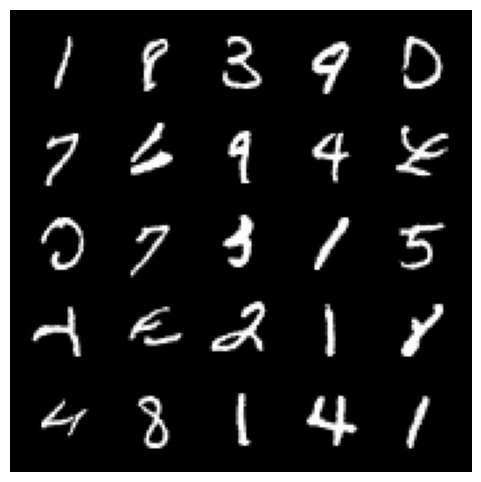

[DDPM->CLF] 1st row preds: [1, 8, 3, 9, 0]
[DDPM->CLF] 1st row preds: [1, 8, 3, 9, 0]
[DDPM->CLF] 2nd row preds: [7, 6, 9, 4, 8]
[DDPM->CLF] 3rd row preds: [0, 7, 3, 1, 5]
[DDPM->CLF] 4th row preds: [4, 2, 2, 1, 8]
[DDPM->CLF] 5th row preds: [4, 8, 1, 4, 1]
[DDPM->CLF] confidences: [1.0, 1.0, 1.0, 0.99, 1.0]
[DDPM->CLF] confidences: [1.0, 0.95, 1.0, 1.0, 0.89]
[DDPM->CLF] confidences: [1.0, 1.0, 0.99, 1.0, 1.0]
[DDPM->CLF] confidences: [1.0, 0.64, 1.0, 1.0, 1.0]
[DDPM->CLF] confidences: [1.0, 1.0, 1.0, 1.0, 1.0]


In [ ]:
@torch.no_grad()
def classify_and_show(ddpm_samples_raw: torch.Tensor, nrow: int = 5):
    """
    ddpm_samples_raw: [B,1,28,28] in [-1,1]
    """
    clf.eval()

    # pull in the ddpm_raw samples, convert them from [-1,1] to [0,1], then MNIST normalize
    x_clf = ddpm_raw_to_clf_input(ddpm_samples_raw).to(device)
    
    logits = clf(x_clf)
    probs  = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1).cpu()

    # Visualization: show images in [0,1] regardless of classifier space
    vis = (ddpm_samples_raw.clamp(-1, 1) + 1) / 2
    grid = make_grid(vis, nrow=nrow, padding=6)
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.show()


    print("[DDPM->CLF] 1st row preds:", preds[0:5].detach().cpu().tolist())
    print("[DDPM->CLF] 1st row preds:", preds[0:5].detach().cpu().tolist())
    print("[DDPM->CLF] 2nd row preds:", preds[5:10].detach().cpu().tolist())
    print("[DDPM->CLF] 3rd row preds:", preds[10:15].detach().cpu().tolist())
    print("[DDPM->CLF] 4th row preds:", preds[15:20].detach().cpu().tolist())
    print("[DDPM->CLF] 5th row preds:", preds[20:25].detach().cpu().tolist())

    print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[0:5].detach().cpu().tolist()])
    print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[5:10].detach().cpu().tolist()])
    print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[10:15].detach().cpu().tolist()])
    print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[15:20].detach().cpu().tolist()])
    print("[DDPM->CLF] confidences:", [round(x, 2) for x in probs.max(dim=1).values[20:25].detach().cpu().tolist()])



if ddpm_samples_raw is not None:
    _ = classify_and_show(ddpm_samples_raw[:25], nrow=5)


## 4) What to change in your diffusion sampling code

If you keep this notebook's default `INPUT_SPACE='01_norm'`:

- Keep your existing `ddpm_samples_raw = undo_precond(...).clamp(-1,1)`.
- For classification, convert to `[0,1]` and normalize with MNIST mean/std:

```python
ddpm_samples_01 = (ddpm_samples_raw + 1) / 2
ddpm_samples_clf = (ddpm_samples_01 - 0.1307) / 0.3081
pred = clf(ddpm_samples_clf.to(device)).argmax(1)
```